In [23]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import geometry
import rioxarray as rxr
from rasterio.features import shapes
import osmnx as ox
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import contextily as cx
from MODE_top_level import RegionalModel
from syspy.spatial.spatial import agglomerative_clustering, zone_clusters
from syspy.transitfeed import feed_links

In [2]:
figsize = 16

# Create a regional model

Define the region and generate networks

In [ ]:
region_name = 'SevilleFUA'
west, south, east, north = -6.023388,37.307,-5.894325,37.438819
polygon = geometry.Polygon([(west, south), (east, south), (east, north), (west, north), (west, south)])
regio_df = gpd.GeoDataFrame(index=['inner_city'], geometry=[polygon], crs=4326)
buffer = 0.01
# Add functional urban area
fua_url = 'https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_FUA_UCDB2015_GLOBE_R2019A/V1-0/GHS_FUA_UCDB2015_GLOBE_R2019A_54009_1K_V1_0.zip'
p = f"zip+{fua_url}!GHS_FUA_UCDB2015_GLOBE_R2019A_54009_1K_V1_0.gpkg"
fuas = gpd.read_file(p)
fua = fuas.query(f"eFUA_name == '{region_name[:-3]}'").to_crs(regio_df.crs)
regio_df.loc['city'] = fua.iloc[0,-1]
polygon = fua.iloc[0,-1]
# Init a regional model with quetzal properties
model = RegionalModel(polygon=regio_df.loc['city', 'geometry'], buffer_size=buffer, epsg=4326, coordinates_unit='degree')

In [8]:
# Save the geometry
if not os.path.exists('../model/'+region_name+'/'):
    os.mkdir('../model/'+region_name+'/')
    os.mkdir('../output/'+region_name+'/')
regio_df.to_file('../model/'+region_name+'/region_geometries.geojson', driver='GeoJSON')

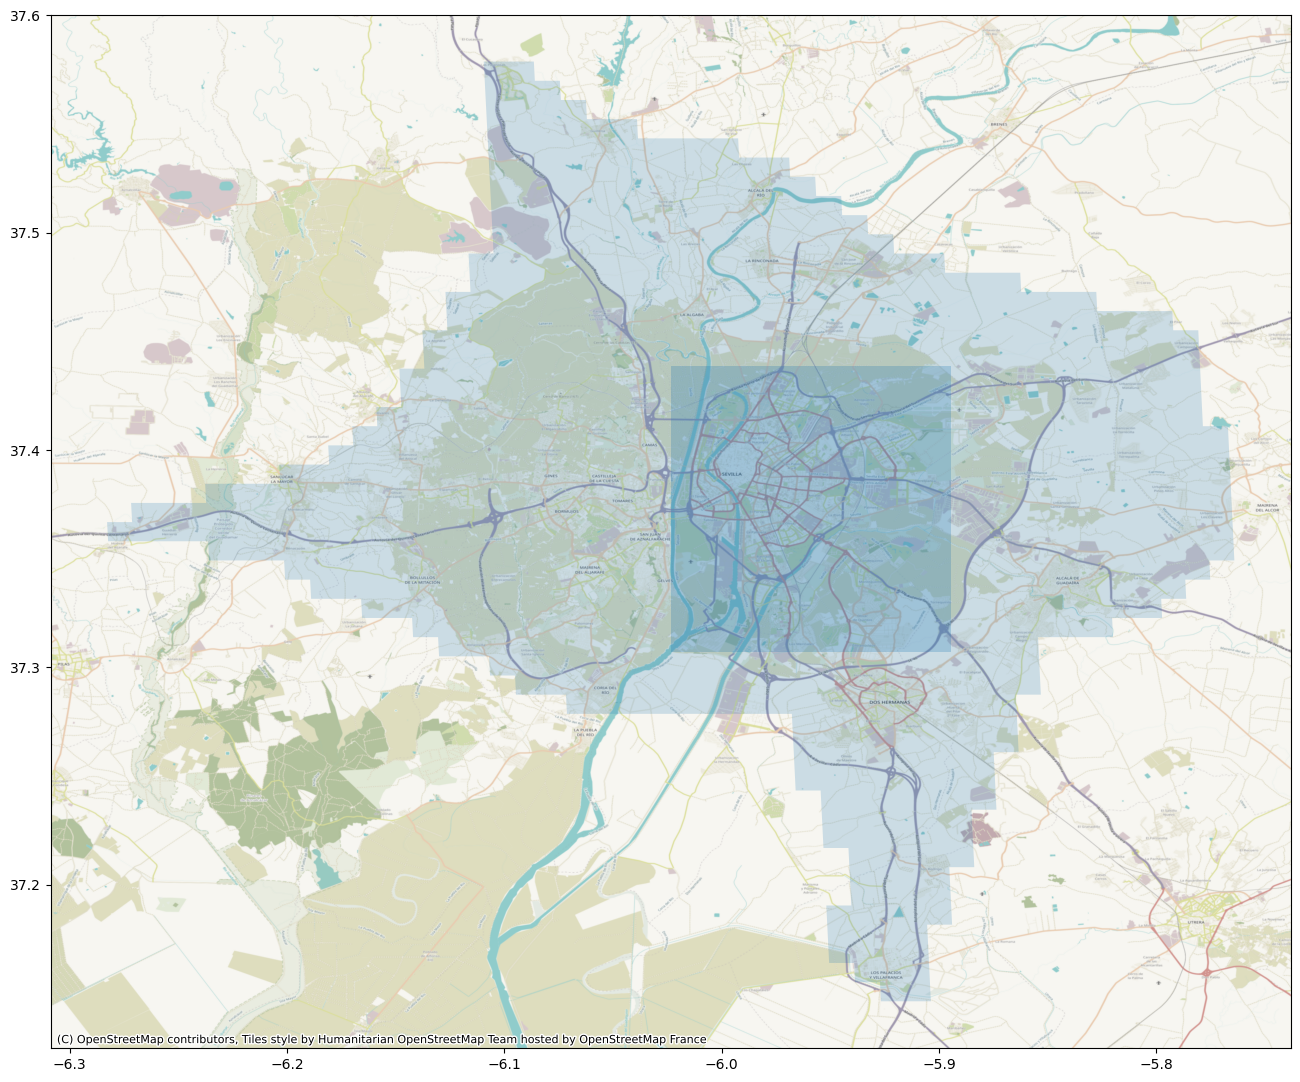

In [9]:
# Plot
regio_df['alpha'] = [1/(i+4) for i in range(len(regio_df))]
plot = regio_df.plot(alpha=regio_df['alpha'], figsize=(figsize, figsize))
cx.add_basemap(ax=plot, crs='EPSG:4326', zoom=13)#, source=cx.providers.OpenStreetMap.Mapnik)
plot.figure.savefig('../output/'+region_name+'/region.png', dpi=400, bbox_inches='tight')

# Road network

Driving, cycling, and walking

In [34]:
# Generate road networks
road_path = '../model/'+region_name+'/networks_road/'
if not os.path.exists(road_path):
    model.generate_street_networks(
        path_to_graphml='../input/OSM_region_'+region_name+'.graphml',
        car=True, bike=True, walk=True,
        bikeable=['designated', 'road_markings', 'small_road', 'path', 'main_road', 'with_foot', 'primary'],
        walkable=['designated', 'on_street', 'unknown'], # main_road
        simplify_strict=False)
    model.save_networks_road(road_path)
else:
    model.load_networks_road(road_path)

try loading from file
load graph from OpenStreetMap: Full detail for study region, only driving networks for buffer area
graph loaded from online source and saved
fix maximum speed from OSM data
fix lane count from OSM data
calculate road capacity
build road network
simplifing car network
fix maximum speed from OSM data
fix lane count from OSM data
calculate road capacity
build cycling network
classify quality of cycling paths
simplifing cycling network
Calculate time on link
classify walking paths
simplifing walking network
Calculate time on link
Stored car networt at: ../model/SevilleFUA/networks_road/
Stored cycle networt at: ../model/SevilleFUA/networks_road/
Stored walking networt at: ../model/SevilleFUA/networks_road/


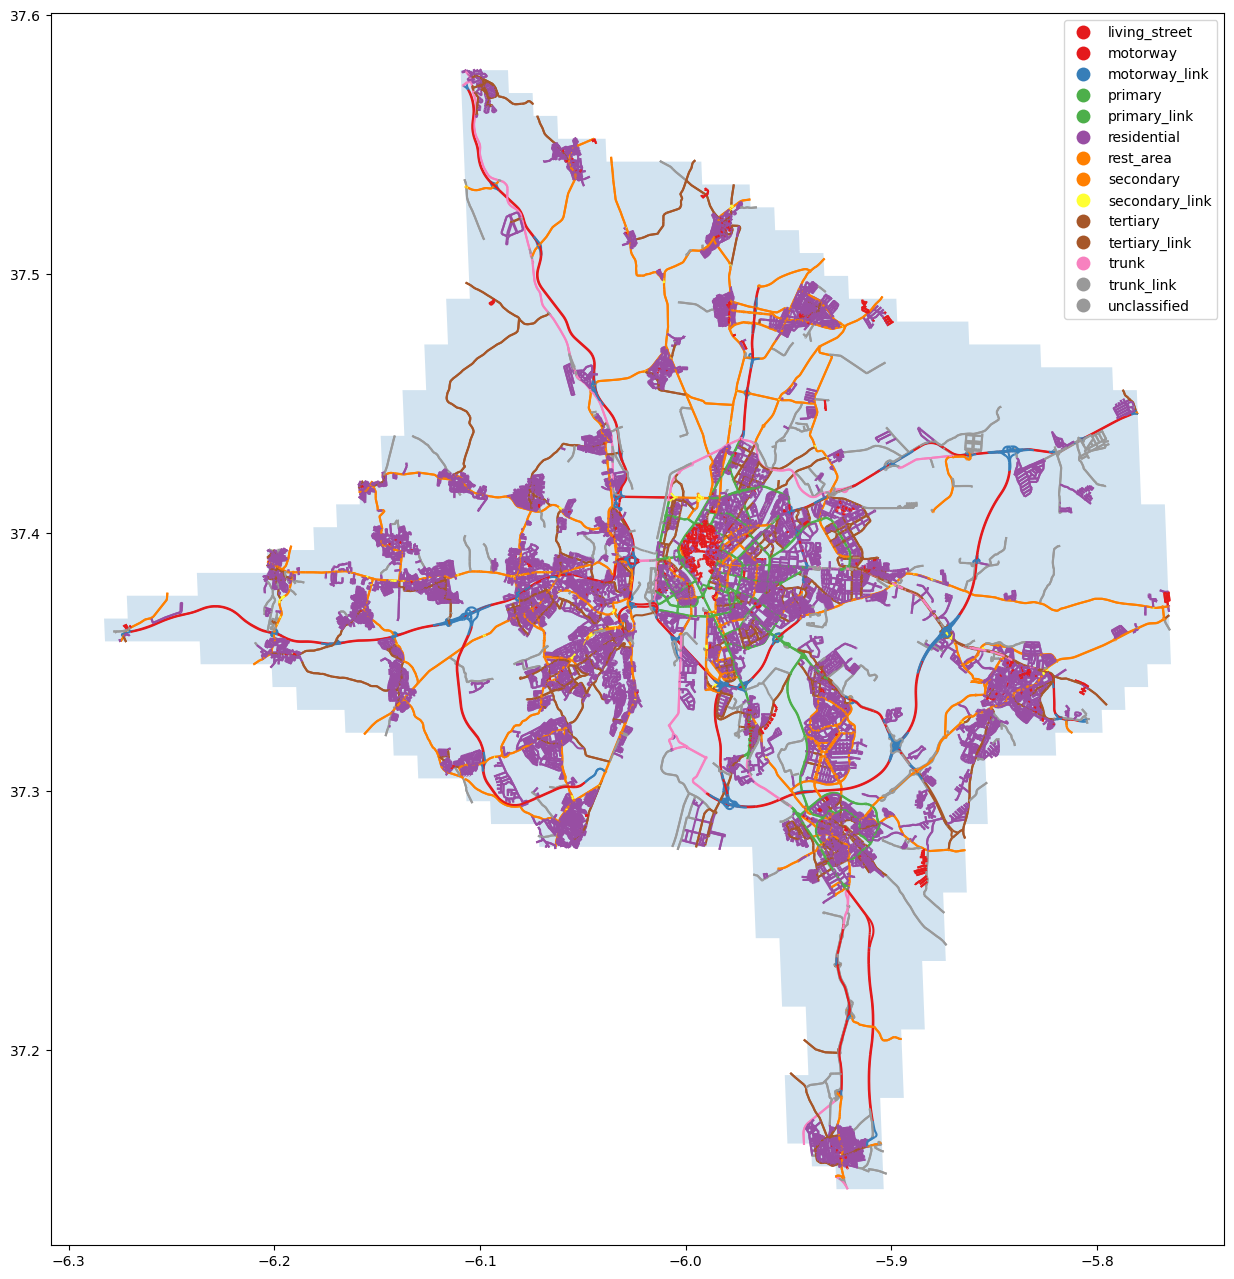

In [35]:
model.auto_links.plot(column='highway', cmap='Set1', legend=True, ax=regio_df.loc[['city']].plot(alpha=0.2, figsize=(figsize, figsize)))
#plt.xlim(west, east)
#plt.ylim(south, north)
plt.savefig('../output/'+region_name+'/network_car.png', dpi=400, bbox_inches='tight')

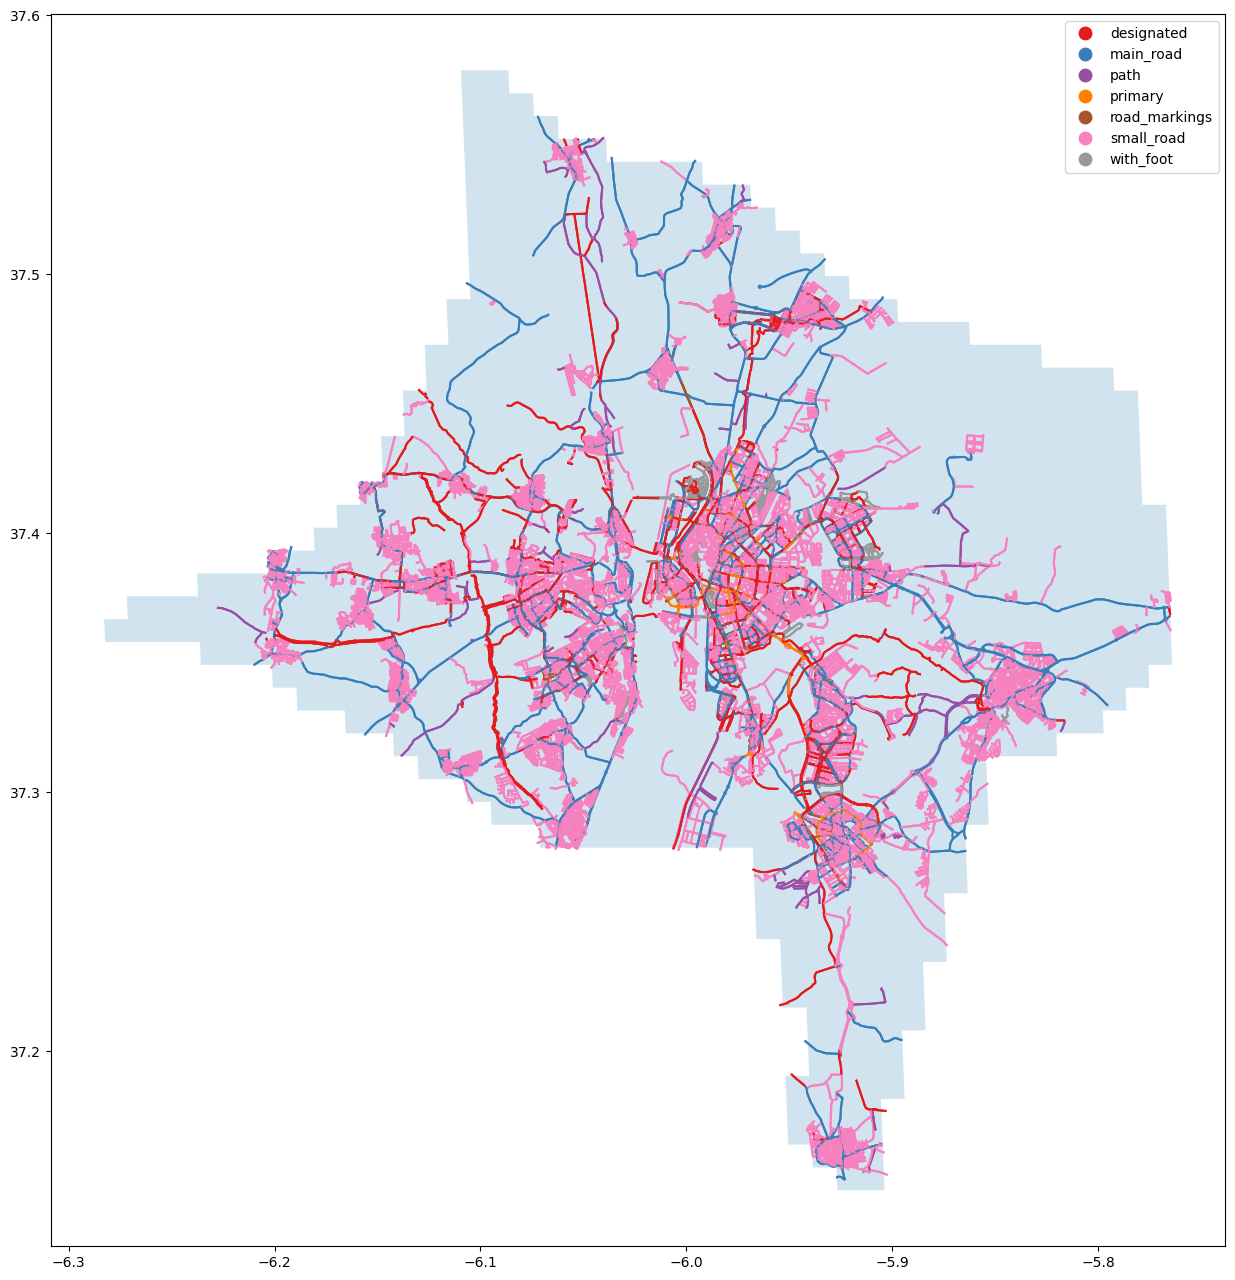

In [36]:
model.cycle_links.plot(column='way_quality', cmap='Set1', legend=True, ax=regio_df.loc[['city']].plot(alpha=0.2, figsize=(figsize, figsize)))
#plt.xlim(west, east)
#plt.ylim(south, north)
plt.savefig('../output/'+region_name+'/network_bicycle.png', dpi=400, bbox_inches='tight')

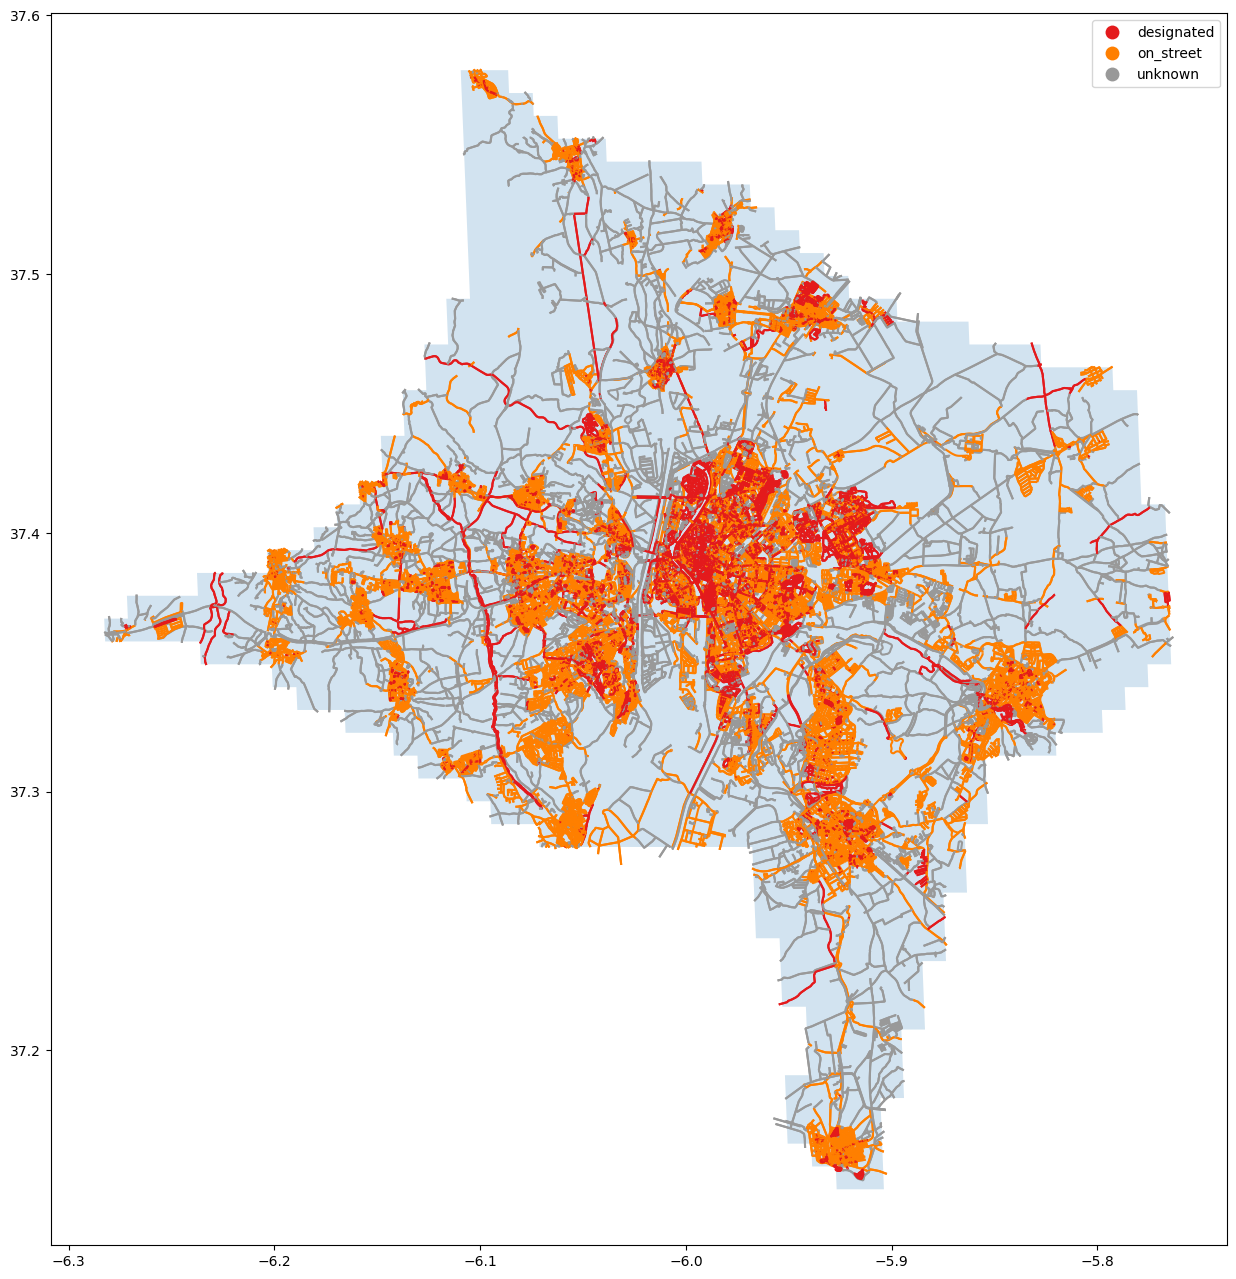

In [37]:
model.walk_links.plot(column='footway_class', cmap='Set1', legend=True, ax=regio_df.loc[['city']].plot(alpha=0.2, figsize=(figsize, figsize)))
#plt.xlim(west, east)
#plt.ylim(south, north)
plt.savefig('../output/'+region_name+'/network_walk.png', dpi=400, bbox_inches='tight')

# Public transit network

Generate pt_links and pt_nodes, also relevant for P&R pathfinding.

In [ ]:
# Generate
pt_path = '../model/'+region_name+'/networks_pt/'
if not os.path.exists(pt_path):
    gtfs_path = '../input/'+region_name+'/GTFS/'
    route_type_dict = {1: 'metro', 2:'train', 3: 'bus'}
    for file in os.listdir(gtfs_path):
        print(file)
        dates = None
        max_shortcut = 1
        if 'Andalusia_buses' in file:
            dates = [str(d) for d in range(20260309, 20260316)]
        elif file.startswith('Sevilla'):
            dates = [str(d) for d in range(20260108, 20260112)]
            max_shortcut = 1000
        elif file.startswith('renfe'):
            dates = ['20260611']
        model.generate_public_transport_network(gtfs_path+str(file),
                                                dates=dates,
                                                route_type_dict=route_type_dict,
                                                remote_stations_for_headway=False,
                                                fix_integrity=False,
                                                max_shortcut=max_shortcut)
    # Save PT networks
    model.pt_links.drop(['level_0', 'index'], axis=1, errors='ignore', inplace=True)
    model.pt_footpaths.drop(['level_0', 'index'], axis=1, errors='ignore', inplace=True)
    model.save_network_pt(pt_path.replace('_pt/', '_pt_no_integrity/'))
    
    # Then perform integrity checks
    #model.fix_pt_network_integrity()
    
    # Fix the broken GTFS times
    model.pt_links.loc[(model.pt_links['trip_id'].str.startswith('2')), 'time'] = \
        model.pt_links.loc[(model.pt_links['trip_id'].str.startswith('2')), 'length'] / (30/3.6)

    # Fix broken sequences
    l = model.pt_links.loc[(model.pt_links['trip_id'].str.startswith('2'))].copy()
    l['index'] = l.index
    l = feed_links.clean_sequences(l, sequence='link_sequence', group_id='trip_id')
    model.pt_links = gpd.GeoDataFrame(pd.concat([
        model.pt_links.loc[(~model.pt_links['trip_id'].str.startswith('2'))],
        l.set_index('index')
    ])).set_crs(regio_df.crs)
    
    # Fix route types
    model.pt_links.loc[model.pt_links['dep_date']=='20260611', 'route_type'] = 'rail'
    
    model.save_network_pt(pt_path)
else:
    model.load_network_pt(pt_path)

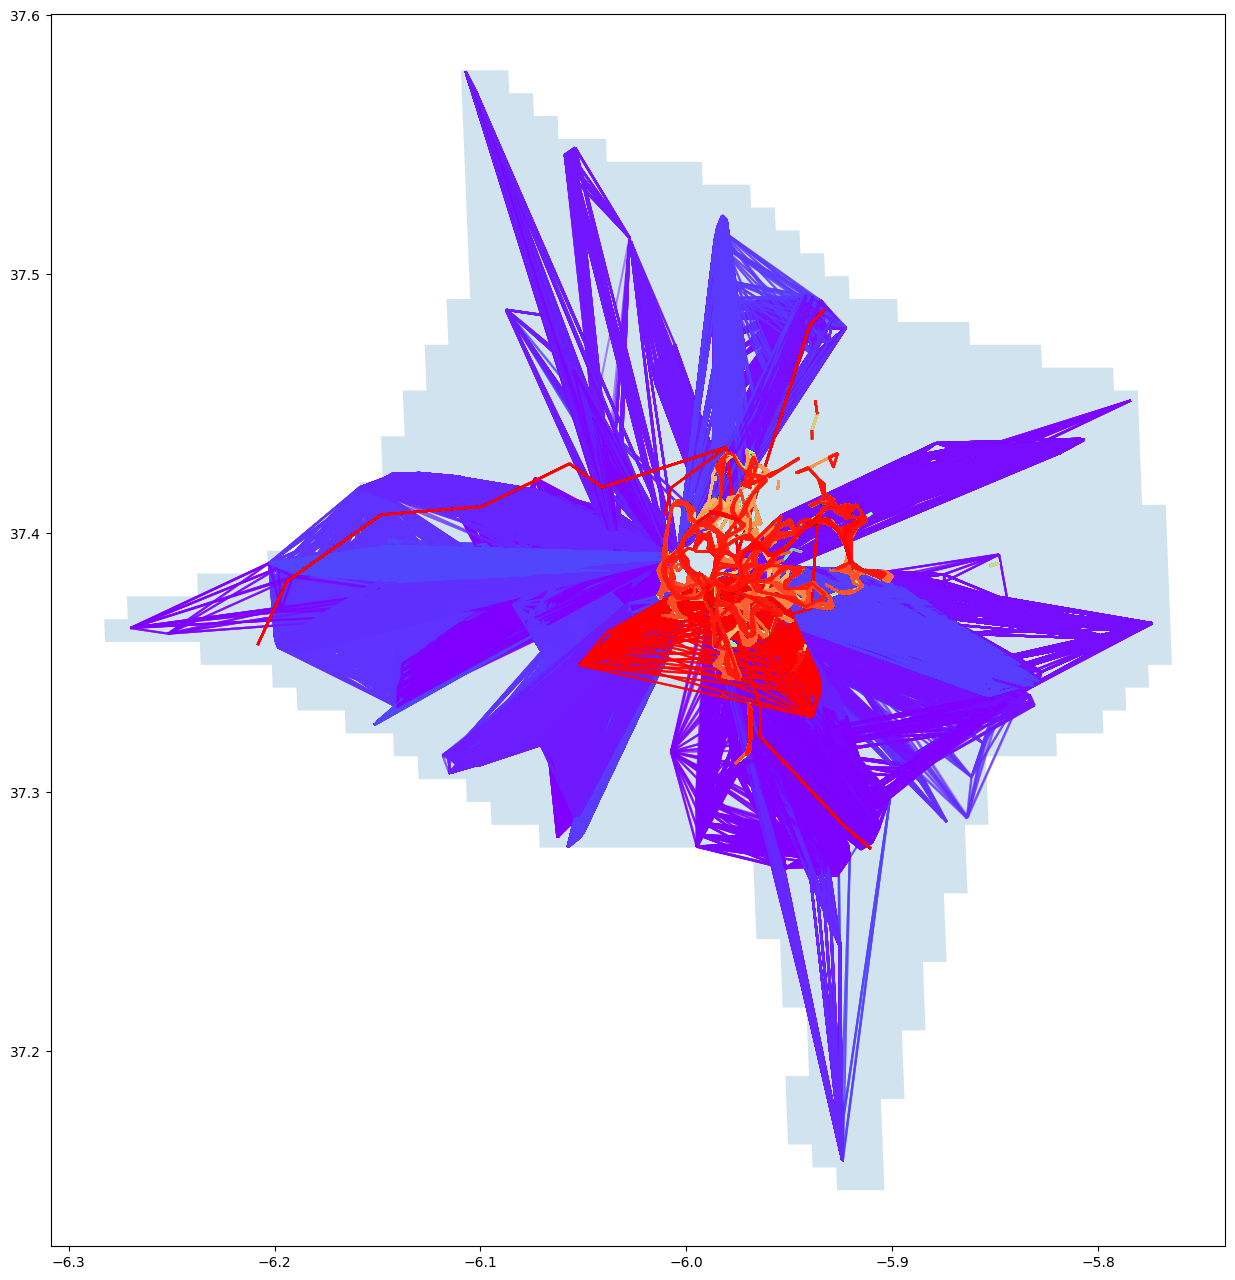

In [31]:
# Plot
model.pt_links.plot(column='trip_id', cmap='rainbow', alpha=.5, ax=regio_df.loc[['city']].plot(alpha=.2, figsize=(figsize, figsize)))
plt.savefig('../output/'+region_name+'/pt_network.png', dpi=400, bbox_inches='tight')

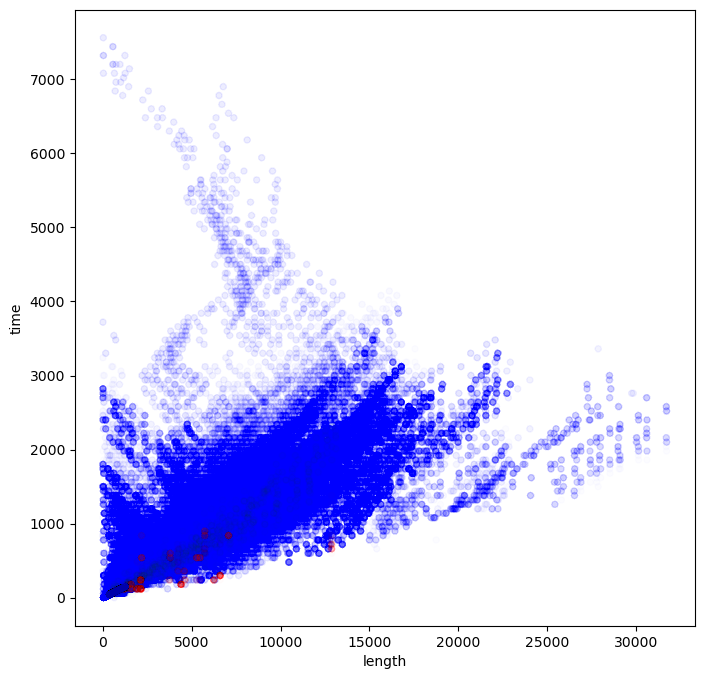

In [38]:
model.pt_links['color'] = model.pt_links['route_type'].map({'bus': 'blue', 'metro': 'green', 'rail': 'red'}).fillna('yellow')
model.pt_links.plot.scatter(x='length', y='time', c='color', alpha=.01, figsize=(figsize/2, figsize/2))
plt.savefig('../output/'+region_name+'/pt_network_speeds.png', dpi=400, bbox_inches='tight')

# POI data

exctract relevant Points of Interest data from OpenStreetMap

In [ ]:
poi_file = '../model/'+region_name+'/pois_raw.geojson'
if not os.path.exists(poi_file):
    # Load from OSM
    tags = {'office': True,
        'amenity': True,
        'leisure': True,
        'shop': True,
        #'tourism': True, # not really relevant for needs satisfaction of local population
        'craft': True,
        'healthcare': True,
        'landuse':['retail','commercial']}
    pois = []
    for tag, values in tags.items():
        poi = ox.features.features_from_polygon(polygon, tags={tag: values})
        poi['tag'] = tag
        poi['type'] = poi[tag]
        poi['area'] = poi.to_crs(3857)['geometry'].area
        poi['geometry'] = poi['geometry'].centroid
        pois.append(poi.reset_index()[['tag', 'type', 'name', 'osmid', 'geometry']])
    pois = pd.concat(pois).drop_duplicates('osmid').reset_index(drop=True)
    #pois = pois.loc[pois['geometry'].within(model.study_region_polygon)]
    # Save
    pois.to_file(poi_file, driver='GeoJSON')
else:
    pois = gpd.read_file(poi_file).to_crs(regio_df.crs)

In [ ]:
count = pois.groupby(['tag', 'type'])['osmid'].count().unstack(0).fillna(0)
count['sum'] = count.sum(axis=1)
count = count.sort_values('sum', ascending=False)
count.loc[count['sum']>=20].drop('sum', axis=1).plot.bar(stacked=True, cmap='summer', figsize=(figsize,figsize/4))
plt.savefig('../output/'+region_name+'/poi_frequency.png', dpi=400, bbox_inches='tight')

In [ ]:
# Show those with low frequencies
str(count.loc[(count['sum']<20)&(count['sum']>2)].index.tolist())

In [ ]:
# Assign POIs to trip purposes
purpose_desc = {
    '1': 'commuting',
    '2': 'education',
    '3': 'accompaniment',
    '41': 'social',
    '42': 'cultural',
    '51': 'groceries',
    '52': 'errands',
    '6': 'healthcare',
    '7': 'recreational'
}
purpose_pois = {
    '2': ['school', 'university', 'college', 'educational_institution'], # education
    '3': ['playground', 'kindergarten', 'childcare'], # accompaniment
    '41': ['restaurant', 'bar', 'cafe', 'pub', 'community_centre', 'social_facility', 'kitchen',
           'nightclub', 'nursing_home', 'biergarten', 'social_centre', 'social_club', 'townhall',
           'bowling_alley'], # social
    '42': ['events_venue', 'place_of_worship', 'theatre', 'dance', 'stadium', 'cinema', 'religion'], # cultural
    '51': ['supermarket', 'convenience', 'bakery', 'butcher', 'seafood', 'marketplace', 'grocery'], # groceries
    '52': ['pharmacy', 'variety_store', 'hardware', 'mall', 'laundry', 'post_office', 'copyshop',
           'department_store'], # errands
    '6': ['clinic', 'dentist', 'doctors', 'hospital'], # healthcare
    '7': ['garden', 'pitch', 'park', 'swimming_pool', 'sports_centre', 'outdoor_seating',
          'fitness_centre', 'fitness_station', 'sports', 'dog_park', 'library', 'track',
          'sports_hall', 'picnic_table', 'music_school', 'dojo', 'water_park', 'training',
          'yoga', 'horse_riding', 'trail_riding_station'], # recreational, outdoors
}
other = ['clothes', 'bank', 'fast_food', 'hairdresser', 'kiosk', 'gift', 'greengrocer', 'shoes',
         'fuel', 'beauty', 'jewelry', 'car_repair', 'ice_cream', 'government', 'estate_agent',
         'stationery', 'optician', 'car_wash', 'waste_disposal', 'insurance', 'tobacco', 'company',
         'commercial', 'florist', 'interior_decoration', 'lottery', 'furniture', 'confectionery',
         'taxi', 'pastry', 'retail', 'language_school', 'telecommunication', 'lawyer', 'veterinary',
         'police', 'books', 'computer', 'electronics', 'motorcycle', 'travel_agency', 'association',
         'chemist', 'deli', 'dry_cleaning', 'mobile_phone', 'fashion_accessories',
         'driving_school', 'car_rental', 'herbalist', 'architect', 'cosmetics', 'toys', 'fabric',
         'boutique', 'research', 'pet', 'common', 'employment_agency', 'tailor', 'trade', 'antiques',
         'builder', 'tattoo', 'art', 'photo', 'sewing', 'gambling', 'paint', 'perfumery', 'arts_centre',
         'diplomatic', 'pottery', 'electrical', 'physiotherapist', 'medical_supply', 'car_parts',
         'ngo', 'shoemaker', 'dressmaker', 'newsagent', 'hearing_aids', 'gardener', 'houseware', 'it',
         'plumber', 'electronics_repair', 'hairdresser_supply', 'tea', 'doityourself', 'podiatrist',
         'musical_instrument', 'craft', 'tax_advisor', 'vacuum_cleaner', 'doors', 'fishing', 'food_court',
         'watches', 'pawnbroker', 'wine', 'tyres', 'logistics', 'pet_grooming', 'window_construction',
         'carpenter', 'curtain', 'property_management', 'motorcycle_repair', 'music', 'accountant',
         'funeral_directors', 'garden_centre', 'advertising_agency', 'photographer', 'fire_station',
         'bookmaker', 'coffee', 'bag', 'bleachers', 'studio', 'glaziery', 'political_party', 'locksmith',
         'lighting', 'brewery', 'prep_school', 'leather', 'mobile_phone_accessories', 'general', 'games',
         'laboratory', 'printer_ink', 'frame', 'upholsterer', 'e-cigarette', 'massage', 'wholesale',
         'adult_gaming_centre', 'baby_goods', 'video_games', 'key_cutter', 'courthouse', 'escape_game',
         'security', 'state_agent', 'frozen_food', 'storage_rental', 'sauna', 'golf_course', 'handicraft',
         'health_food', 'coworking', 'hifi', 'travel_agent', 'charity', 'clockmaker', 'repair', 'rigger',
         'union', 'publisher', 'research_institute', 'psychotherapist', 'household_linen', 'party',
         'jeweller', 'anime', 'appliance', 'consulting', 'bookbinder', 'bureau_de_change', 'foundation',
         'financial_advisor', 'farm', 'casino', 'caterer', 'esoteric', 'erotic', 'centre', 'engineer',
         'energy_supplier', 'electrician', 'conference_centre', 'animal_boarding', 'guide', 'alcohol',
         'labor_union', 'monastery', 'money_transfer', 'newspaper', 'marina', 'notary', 'academy',
         'metal_construction']
commuting_pois = sum([l for p,l in purpose_pois.items() if p!= '7'], []) + other
purpose_pois['1'] = [] #commuting_pois
# Check for misspelling
for p, poi_list in purpose_pois.items():
    for poi in poi_list:
        assert len(pois.loc[pois['type']==poi])>0, 'POI not found: ' + poi

# Create separate file for commuting
commuting = pois.loc[pois['type'].isin(commuting_pois)].copy()

# Create columns for trip purposes
for purpose, values in purpose_pois.items():
    pois[purpose] = pois['type'].isin(values)
    commuting[purpose] = commuting['type'].isin(values)

In [ ]:
# Plot POI distribution
plot = model.walk_links.loc[model.walk_links['geometry'].within(model.study_region_polygon)
                            ].plot(color='black', alpha=0.1, figsize=(figsize,figsize))
colors = iter(cm.rainbow(np.linspace(0, 1, len(purpose_pois))))
sizes = {'1': 2, '2': 20, '3': 20, '41': 15, '42': 15, '51':10, '52': 15, '6': 20, '7': 5}
for purpose, values in purpose_pois.items():
    try:
        a = 0.4 if purpose=='1' else 0.8
        pois.loc[pois[purpose]].plot(markersize=sizes[purpose], color=next(colors), alpha=a, label=purpose_desc[purpose], ax=plot)
    except ValueError:
        pass
plot.legend()
plt.savefig('../output/'+region_name+'/pois.png', dpi=400, bbox_inches='tight')

In [ ]:
# Create one activity column
pois['activity'] = 'nan'
for p, types in purpose_pois.items():
    pois.loc[pois[p], 'activity'] = p
    print(purpose_desc[p], len(pois.loc[pois[p]]))
commuting['activity'] = '1'
print(purpose_desc['1'], len(commuting))

In [ ]:
len(pois.loc[pois['activity']!='nan'])

# Residential housing

Get population distribution and locations of residential buildings

In [ ]:
# Get population from GHSL
pop_url = 'https://cidportal.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_MT_GLOBE_R2023A/GHS_POP_E2025_GLOBE_R2023A_54009_250/V1-0/tiles/GHS_POP_E2025_GLOBE_R2023A_54009_250_V1_0_13_11.zip'
#p = f"zip+{url}!GHS_POP_E2025_GLOBE_R2023A_54009_250_V1_0_13_11.tif"
p = '../input/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0.tif'
ghsl_pop = rxr.open_rasterio(p, masked=True, chunks={"x": 2048, "y": 2048})
ghsl_pop = ghsl_pop.rio.clip(regio_df.to_crs(ghsl_pop.rio.crs).geometry, from_disk=True)

In [ ]:
# Use population cell centroids as residential housing
pop = ghsl_pop.compute()
residential = gpd.GeoDataFrame.from_features(
    [{"properties": {"pop": v}, "geometry": s} for i, (s, v) in enumerate(
        shapes(pop.values, mask=~pop.isnull().values, transform=pop.rio.transform()))
    ],
    crs=pop.rio.crs)
residential = residential.loc[residential['pop']>0]
residential.geometry = residential.centroid
residential = residential.to_crs(regio_df.crs)
len(residential)

In [ ]:
plot = residential.plot(column='pop', alpha=.5, markersize=.3, legend=True, figsize=(figsize/2, figsize/2))
plot = regio_df.boundary.plot(color='red', ax=plot)
cx.add_basemap(ax=plot, crs=residential.crs, zoom=13)#, source=cx.providers.OpenStreetMap.Mapnik)
plot.figure.savefig('../output/'+region_name+'/population_density.png', dpi=400, bbox_inches='tight')

# Cluster POIs

Cluster population and POIs into useful zones for fast computation

In [ ]:
# Clip origins to region of analysis
o = residential.loc[residential['geometry'].apply(lambda g: not g.within(regio_df.loc['city', 'geometry']))]

# Now cluster into zones
clusters, cluster_series = zone_clusters(o, n_clusters=50)
clusters = gpd.GeoDataFrame(clusters).set_crs(regio_df.crs)
clusters['centroid'] = clusters.centroid
clusters['cluster'] = clusters.index.map(lambda i: str(i)+'_home')
if 'pop' in o.columns:
    o['cluster'] = cluster_series
    o_pop = o.groupby('cluster')['pop'].sum()
    clusters['pop'] = o_pop
    clusters = clusters.loc[clusters['pop']>1000]
    print('Number of origin zones:', len(clusters))
else:
    clusters['pop'] = 1
o = clusters[['cluster', 'centroid', 'pop']].rename(
    columns={'cluster':'origin_id', 'centroid':'origin', 'pop': 'dest_weight'}
).copy()
o['activity'] = '0'
# Save for later results analysis
clusters.reset_index(drop=True).drop('centroid', axis=1)\
    .to_file('../model/'+region_name+'/zones.geojson', driver='GeoJSON')
# plot
plot = clusters.plot(column='pop', alpha=.3, legend=False, figsize=(figsize/2, figsize/2))
plot = o['origin'].plot(color='red', markersize=.2, ax=plot)
cx.add_basemap(ax=plot, crs=residential.crs, zoom=13, source=cx.providers.CartoDB.Positron)
plot.figure.savefig('../output/'+region_name+'/clustered_zones.png', dpi=400, bbox_inches='tight')

In [ ]:
# Cluster commuting zones agglomeratively
work = commuting.copy().to_crs(epsg=3857)
work['cluster'] = agglomerative_clustering(work, distance_threshold=4000)
work['cluster'] = work['cluster'].apply(lambda i: str(i)+'_work')
work_count = work.groupby('cluster')['type'].count()
work = work.groupby('cluster').apply(lambda g: g['geometry'].union_all().centroid).to_frame()
work['size'] = work_count
work = gpd.GeoDataFrame(work).set_geometry(0).set_crs(epsg=3857).to_crs(epsg=4326).reset_index()
work = work[['cluster', 0, 'size']].rename(columns={'cluster':'origin_id', 0:'origin', 'size':'dest_weight'}).drop_duplicates()
work['activity'] = '1'
print('Number of commuting clusters', len(work))
# plot
plot = work['origin'].plot(color='red', markersize=work_count, alpha=.5, figsize=(figsize/2, figsize/2))
plot = clusters.plot(column='pop', alpha=.3, legend=False, ax=plot)
cx.add_basemap(ax=plot, crs=residential.crs, zoom=13, source=cx.providers.CartoDB.Positron)
plot.figure.savefig('../output/'+region_name+'/work_clustered_zones.png', dpi=400, bbox_inches='tight')

In [ ]:
# Cluster other POIs agglomeratively
poi_zones = {}
for i, (p, name) in enumerate(purpose_desc.items()):
    if len(pois.loc[pois['activity']==p]) > 1:
        df = pois.loc[pois[p]].copy().to_crs(epsg=3857)
        df['cluster'] = agglomerative_clustering(df, distance_threshold=len(df)/1.6+100)
        df['cluster'] = df['cluster'].apply(lambda i: str(i)+'_'+name)
        count = df.groupby('cluster')['type'].count()
        df = df.groupby('cluster').apply(lambda g: g['geometry'].union_all().centroid).to_frame()
        df['size'] = count
        df = gpd.GeoDataFrame(df).set_geometry(0).set_crs(epsg=3857).to_crs(epsg=4326).reset_index()
        df = df[['cluster', 0, 'size']].rename(columns={'cluster':'origin_id', 0:'origin', 'size':'dest_weight'}).drop_duplicates()
        df['activity'] = p
        print(f'Number of {name} clusters', len(df))
        poi_zones[p] = df

# plot
fig, axs = plt.subplots(2, int(round(len(poi_zones)/2)), figsize=(figsize, figsize), sharex='all', sharey='all')
for ax, p, df in zip(axs.flat, poi_zones.keys(), poi_zones.values()):
    ax.set_title(purpose_desc[p])
    df['origin'].plot(color='red', markersize=df['dest_weight'], alpha=.5, ax=ax)
    clusters.plot(column='pop', alpha=.3, legend=False, ax=ax)
    cx.add_basemap(ax=ax, crs=residential.crs, zoom=13, source=cx.providers.CartoDB.Positron)
plt.savefig('../output/'+region_name+'/pois_clustered_zones.png', dpi=400, bbox_inches='tight')

In [ ]:
# Save POIs
merged = pd.concat([work]+list(poi_zones.values()))
merged['geometry'] = merged['origin']
merged = gpd.GeoDataFrame(merged.drop('origin', axis=1)).set_crs(regio_df.crs)
merged.to_file('../model/'+region_name+'/pois.geojson', driver='GeoJSON')